# Method runtime and performance overview

Runtime/status outcomes across viral RNAs, mean Recall–Precision tradeoff, and failure-aware F1 ranking with runtime.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Arial"], "axes.unicode_minus": False})
sns.set_theme(style="white", font="Arial")

excel_path, results_file, fig_dir = Path("../data/runtime.xlsx"), Path("results_virus_scores.xlsx"), Path("fig")
fig_dir.mkdir(exist_ok=True)
VIRUS_ID_ORDER = [
    "IAV-NS", "IAV-M", "IAV-NA", "IAV-NP", "IAV-HA", "IAV-PA", "IAV-PB1", "IAV-PB2",
    "TBSV-T100", "HIV-1-NL4-3", "SIVmac239", "HCV-1b-Con1", "HCV-2a-Jc1", "HCV-2a-JFH1",
    "DENV1-EDEN2402", "DENV2-EDEN3295", "DENV3-EDEN863", "DENV4-EDEN2270",
    "ZIKV-Singapore", "ZIKV-Brazil", "ZIKV-African", "ZIKV-FrenchPolynesia", "ZIKV-Asian",
    "VEEV-ZPC738", "SINV-Girdwood", "CHIKV-StMartin", "PEDV-AJ1102", "SARS-CoV-2",
]
_virus_fasta_lines = [ln.strip() for ln in Path("../data/viruses.fasta").read_text().splitlines() if ln.strip()]
_virus_len_by_header = {_virus_fasta_lines[i][1:]: len(_virus_fasta_lines[i + 1]) for i in range(0, len(_virus_fasta_lines), 3)}
seq_len_map = {
    vid: _virus_len_by_header[f"virus{i}"]
    for i, vid in enumerate(VIRUS_ID_ORDER, start=1)
}

runtime_df = pd.read_excel(excel_path, sheet_name="Runtime")
status_df = pd.read_excel(excel_path, sheet_name="status")
status_matrix = status_df.set_index("method")
runtime_long = runtime_df.melt(id_vars="method", var_name="sequence", value_name="runtime")
plot_df = runtime_long.dropna(subset=["runtime"])

results = pd.read_excel(results_file)
mean_plot_data_rp = results[["Method", "Sensitivity", "Precision"]].dropna().groupby("Method", as_index=False).mean()


In [2]:
METHOD_GROUPS = [
    ("SF", ["LinearFold", "LinearPartition","RNAfold", "EternaFold", "CONTRAfold", "RNAstructure",
             "CENTROIDFOLD", "ShapeKnots", "ProbKnot",  "RNAshapes", "pKiss"]),
    ("DL", ["SPOT-RNA", "RFold"]),
    ("FM", ["ERNIE-RNA", "RiNALMo", "RNA-FM"]),
    ("Hybrid", ["rna-state-inf", "BPfold", "MXfold2", "KnotFold"]),
]
STATUS_COLORS = {
    "Success": "#cff1ff7a", "Success, no pairs": "#b3e7fcd3", "Position embedding limit": "#F1DDDC",
    "GPU out of memory": "#afadb83e", "Timeout": "#e6b6082f", "Preprocessing failure": "#7676D44B",
    "Program crash": "#80C6C17A",
}
STATUS_ORDER = [
    "Success", "Success, no pairs", "Position embedding limit", "GPU out of memory",
    "Program crash", "Preprocessing failure", "Timeout",
]
CATEGORY_MARKERS = {"SF": "o", "DL": "^", "FM": "s", "Hybrid": "D"}
method_to_category = {method: category for category, methods in METHOD_GROUPS for method in methods}
DISTINCT_COLORS_RP = [
    "#1F4E79", "#A03A3A", "#C45C5C", "#6B4C9A", "#C4A035", "#4A6FA5", "#2E75B6",
    "#D4896A", "#D65D7A", "#8E6BB8", "#B05A2A", "#5B9BD5", "#3D9B6E", "#8B6914",
    "#4AADAD", "#9A6B8A", "#B8922A", "#7A5A3A", "#2A8A8A", "#6BBF8A",
]
all_methods_rp = [m for _, methods in METHOD_GROUPS for m in methods if m in set(mean_plot_data_rp["Method"])]
color_map_rp = {m: DISTINCT_COLORS_RP[i % len(DISTINCT_COLORS_RP)] for i, m in enumerate(all_methods_rp)}
color_map_rp["LinearPartition"] = "#A03A3A"
color_map_rp["RNAfold"] = "#0F766E"
marker_map_rp = {m: CATEGORY_MARKERS[method_to_category[m]] for m in all_methods_rp}


def build_grouped_methods(status_index):
    available_methods = set(status_index)
    grouped_methods, ordered_methods = [], []
    for group_name, methods in METHOD_GROUPS:
        present_methods = [method for method in methods if method in available_methods]
        if present_methods:
            grouped_methods.append((group_name, present_methods))
            ordered_methods.extend(present_methods)
    return grouped_methods, ordered_methods


## Runtime status heatmap


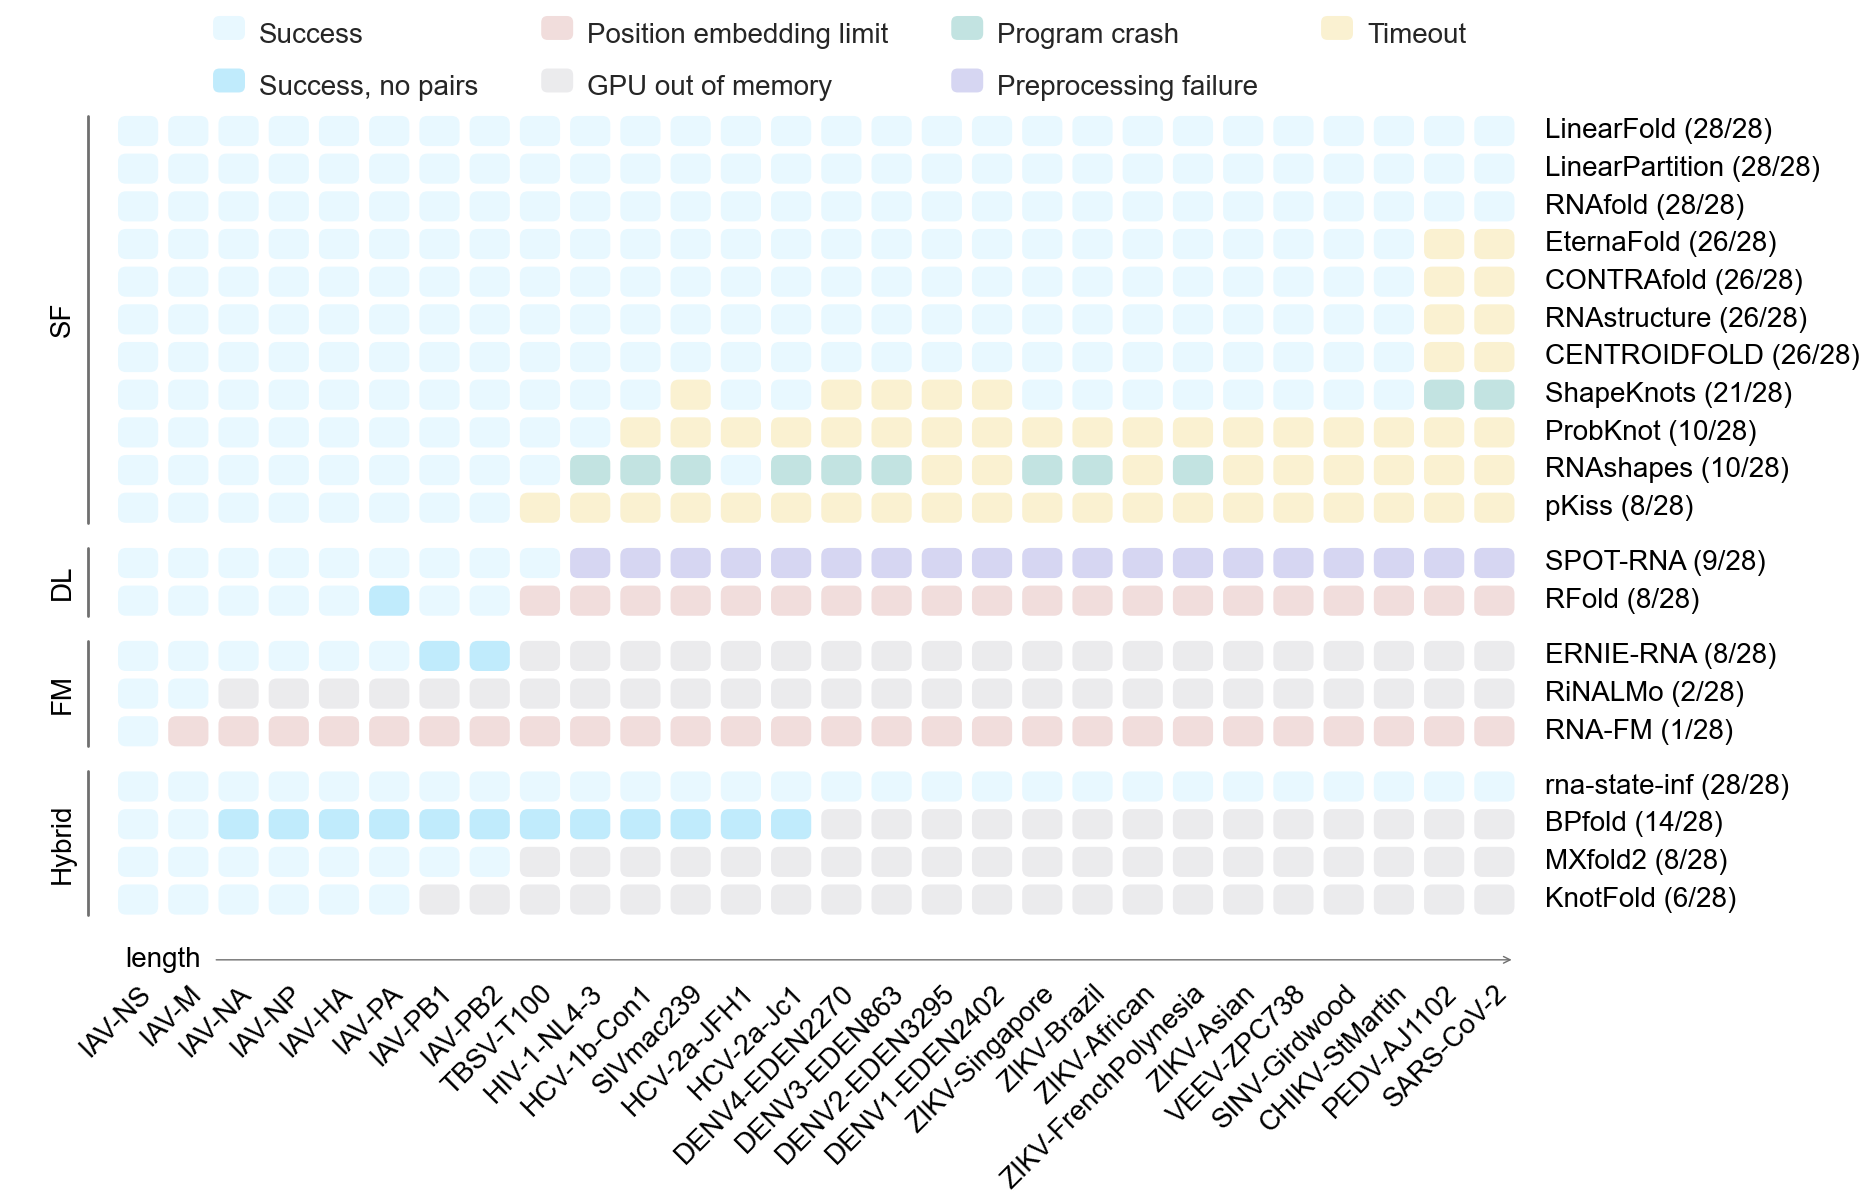

In [3]:
from matplotlib.legend_handler import HandlerBase

grouped_methods, ordered_methods = build_grouped_methods(status_matrix.index)
grouped_status = status_matrix.loc[ordered_methods]

fig, ax = plt.subplots(figsize=(28, 12), facecolor="white")
ax.set_facecolor("white")

group_label_x, group_line_x = -1.5, -1
method_label_x = grouped_status.shape[1]
arrow_x0_data, cell_width, cell_height = 1.5, 0.8, 0.6
arrow_x1_data = grouped_status.shape[1] - 1 + cell_width / 2.0
arrow_y_offset, length_x_data, legend_y = 1.2, arrow_x0_data - 0.25, 1.12
x_tick_pad, left_margin, right_margin = 2, 0.12, 0.865
bottom_margin, top_margin, rounding, group_gap, row_pitch = 0.16, 0.88, 0.16, 0.35, 0.75

row_positions, group_ranges, current_y = [], [], 0.0
for group_index, (group_name, methods) in enumerate(grouped_methods):
    start_y = current_y
    for _ in methods:
        row_positions.append(current_y)
        current_y += row_pitch
    end_y = current_y - row_pitch
    group_ranges.append((group_name, start_y - cell_height / 2.0, end_y + cell_height / 2.0, (start_y + end_y) / 2.0))
    if group_index < len(grouped_methods) - 1:
        current_y += group_gap

arrow_y_data = row_positions[-1] + arrow_y_offset
for row_index, y in enumerate(row_positions):
    for col_index in range(grouped_status.shape[1]):
        status_name = grouped_status.iloc[row_index, col_index]
        ax.add_patch(FancyBboxPatch(
            (col_index - cell_width / 2.0, y - cell_height / 2.0), cell_width, cell_height,
            boxstyle=f"round,pad=0,rounding_size={rounding}", linewidth=0,
            facecolor=STATUS_COLORS[status_name], edgecolor="none",
        ))

for group_name, line_y0, line_y1, center_y in group_ranges:
    ax.plot([group_line_x, group_line_x], [line_y0, line_y1], color="#6f6f6f", linewidth=2.0, solid_capstyle="round", zorder=1)
    ax.text(group_label_x, center_y, group_name, va="center", ha="center", rotation=90, fontsize=20, color="#000000")

SUCCESS_STATUSES, N_SEQUENCES = {"Success", "Success, no pairs"}, grouped_status.shape[1]
for method_name, y in zip(grouped_status.index, row_positions):
    success_count = grouped_status.loc[method_name].isin(SUCCESS_STATUSES).sum()
    ax.text(method_label_x, y, f"{method_name} ({int(success_count)}/{N_SEQUENCES})", va="center", ha="left", fontsize=20, color="#000000")

ax.set_xticks(range(grouped_status.shape[1]))
ax.set_xticklabels(grouped_status.columns, rotation=45, ha="right", rotation_mode="anchor", fontsize=20, color="#000000")
ax.set_yticks([])
ax.set_aspect("equal", adjustable="box")

ax.annotate("", xy=(arrow_x1_data, arrow_y_data), xytext=(arrow_x0_data, arrow_y_data), xycoords="data", textcoords="data",
            annotation_clip=False, arrowprops=dict(arrowstyle="->", color="#6f6f6f", linewidth=1.0))
ax.text(length_x_data, arrow_y_data, "length", ha="right", va="center", fontsize=20, color="#000000")


class RoundedCellHandler(HandlerBase):
    def __init__(self, cell_width, cell_height, rounding, **kwargs):
        super().__init__(**kwargs)
        self.aspect = cell_width / cell_height
        self.rounding_frac = rounding / cell_height

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        box_height, box_width = height, height * self.aspect
        x0, y0 = xdescent + (width - box_width) / 2.0, ydescent + (height - box_height) / 2.0
        return [FancyBboxPatch(
            (x0, y0), box_width, box_height, boxstyle=f"round,pad=0,rounding_size={self.rounding_frac * box_height}",
            transform=trans, facecolor=orig_handle.get_facecolor(), edgecolor="none", linewidth=0,
        )]


legend_handles = [
    FancyBboxPatch((0, 0), cell_width, cell_height, boxstyle=f"round,pad=0,rounding_size={rounding}",
                   facecolor=STATUS_COLORS[status], edgecolor="none", label=status)
    for status in STATUS_ORDER
]
legend_handle_height = 0.95
legend_handle_length = legend_handle_height * (cell_width / cell_height)
ax.legend(
    handles=legend_handles, handler_map={FancyBboxPatch: RoundedCellHandler(cell_width, cell_height, rounding)},
    fontsize=20, frameon=False, bbox_to_anchor=(0.5, legend_y), loc="upper center", ncol=4,
    handlelength=legend_handle_length, handleheight=legend_handle_height, handletextpad=0.45,
    columnspacing=2.2, labelspacing=0.9, borderaxespad=0.0,
)

ax.set_xlim(-2.55, grouped_status.shape[1] + 2.45)
ax.set_ylim(-0.35, row_positions[-1] + 1.55)
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="x", length=0, pad=x_tick_pad)
ax.tick_params(axis="y", length=0)
plt.subplots_adjust(left=left_margin, right=right_margin, bottom=bottom_margin, top=top_margin)
plt.savefig(fig_dir / "runtime_status_heatmap.pdf", format="pdf", bbox_inches="tight", dpi=350)
plt.show()


## Recall–Precision tradeoff

Mean Recall vs Precision per method.


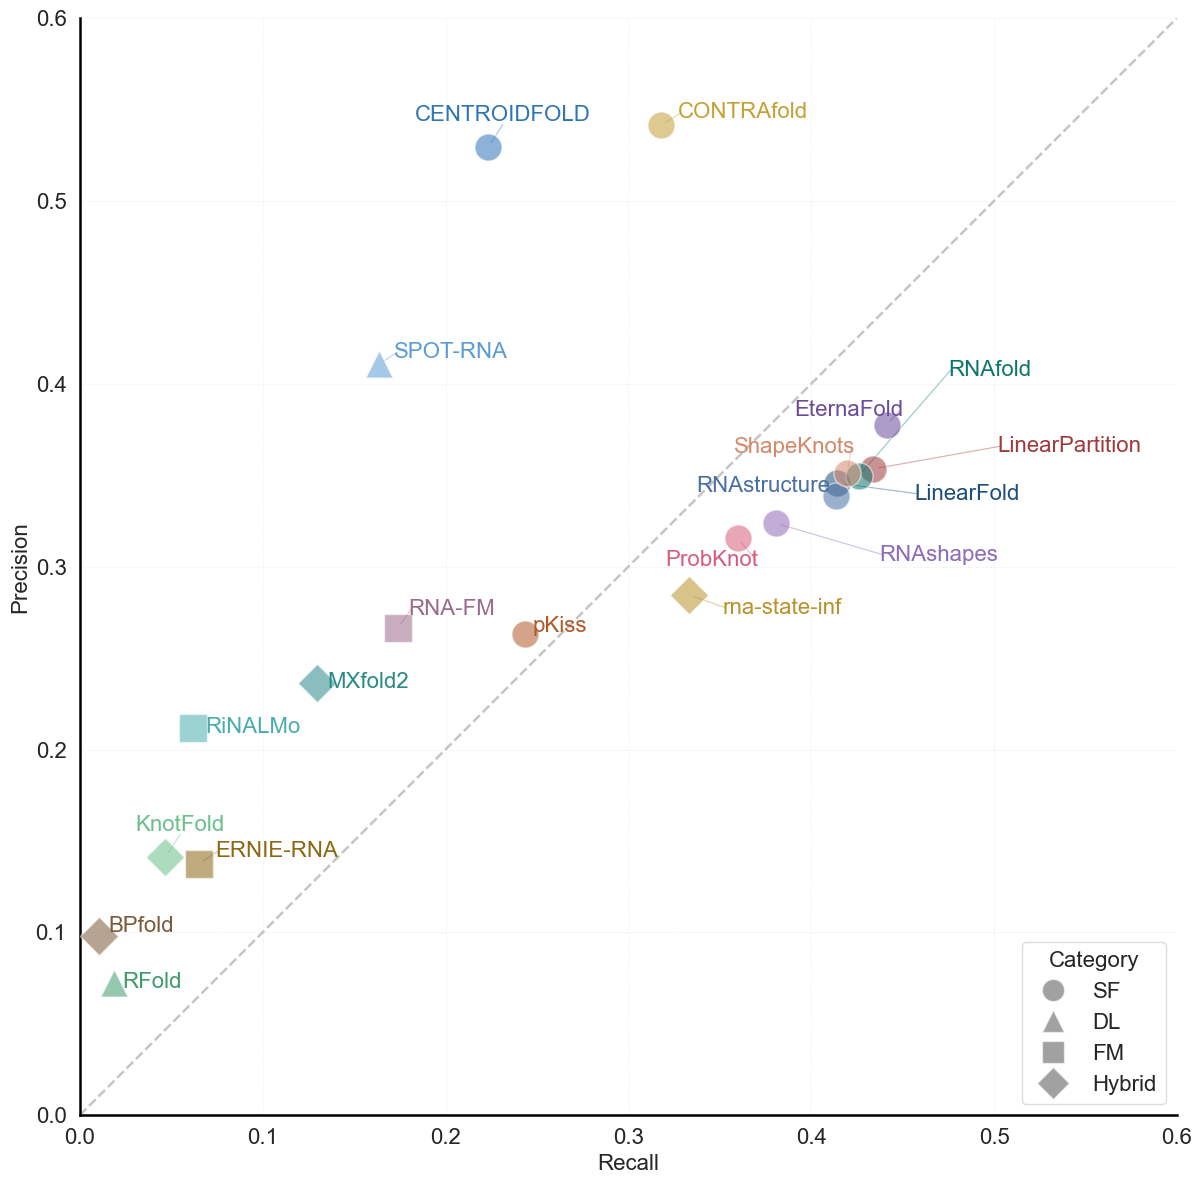

In [4]:
from adjustText import adjust_text
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

fig, ax = plt.subplots(figsize=(14, 12), facecolor="white")
ax.set_facecolor("white")
ax.plot([0, 0.6], [0, 0.6], linestyle="--", color="#BBBBBB", linewidth=1.8, alpha=0.85, zorder=1)

FIXED_ABOVE = {"CENTROIDFOLD", "KnotFold"}
ABOVE_DX, ABOVE_DY = 0.008, 0.012

texts, point_xy, point_colors, fixed_flags = [], [], [], []
for method in all_methods_rp:
    method_data = mean_plot_data_rp[mean_plot_data_rp["Method"] == method]
    if method_data.empty:
        continue
    x, y = float(method_data["Sensitivity"].iloc[0]), float(method_data["Precision"].iloc[0])
    color = color_map_rp[method]
    ax.scatter(x, y, c=color, alpha=0.55, s=380, marker=marker_map_rp[method], linewidths=1.0, edgecolors="white", zorder=3)
    if method in FIXED_ABOVE:
        texts.append(ax.text(
            x + ABOVE_DX, y + ABOVE_DY, method, fontsize=16, color=color,
            ha="center", va="bottom", zorder=4,
        ))
        fixed_flags.append(True)
    else:
        texts.append(ax.text(x, y, method, fontsize=16, color=color, zorder=4))
        fixed_flags.append(False)
    point_xy.append((x, y))
    point_colors.append(color)

ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.6)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Recall", fontsize=16)
ax.set_ylabel("Precision", fontsize=16)
ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_linewidth(1.8)
    ax.spines[side].set_color("black")
ax.tick_params(axis="both", labelsize=16, width=1.8, length=6)

legend_handles = [
    Line2D([0], [0], marker=CATEGORY_MARKERS[cat], color="none", markerfacecolor="#555555",
           markeredgecolor="white", markeredgewidth=1.0, markersize=16, alpha=0.55, label=cat, linestyle="None")
    for cat in ("SF", "DL", "FM", "Hybrid")
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=16, frameon=True, framealpha=0.9,
          edgecolor="0.85", title="Category", title_fontsize=16)

adjust_text(
    [t for t, fixed in zip(texts, fixed_flags) if not fixed],
    ax=ax,
    expand_points=(2.0, 2.0),
    expand_text=(1.6, 1.6),
    force_text=(1.5, 1.5),
    force_points=(1.0, 1.0),
    force_pull=(0.01, 0.01),
    lim=2000,
    max_move=(20, 20),
    min_arrow_len=8,
    ensure_inside_axes=True,
    avoid_self=True,
)

plt.tight_layout()
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
for text, (x, y), color in zip(texts, point_xy, point_colors):
    bbox = text.get_window_extent(renderer=renderer)
    bbox_data = bbox.transformed(ax.transData.inverted())
    left, right = bbox_data.x0, bbox_data.x1
    bottom, top = bbox_data.y0, bbox_data.y1
    mid_x = (left + right) / 2
    mid_y = (bottom + top) / 2
    inset_x = 0.03 * (right - left)
    inset_y = 0.03 * (top - bottom)
    candidates = [
        (left + inset_x, mid_y),
        (right - inset_x, mid_y),
        (mid_x, bottom + inset_y),
        (mid_x, top - inset_y),
    ]
    edge_x, edge_y = min(candidates, key=lambda p: (p[0] - x) ** 2 + (p[1] - y) ** 2)
    if (edge_x - x) ** 2 + (edge_y - y) ** 2 < 1e-4:
        continue
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(edge_x, edge_y),
        arrowprops=dict(
            arrowstyle="-",
            color=to_rgba(color, alpha=0.40),
            lw=0.85,
            shrinkA=0,
            shrinkB=4,
            connectionstyle="arc3,rad=0",
        ),
        zorder=2,
    )

plt.savefig(fig_dir / "recall_precision_tradeoff.pdf", format="pdf", bbox_inches="tight", dpi=350)
plt.show()


## Combined failure-aware ranking and runtime


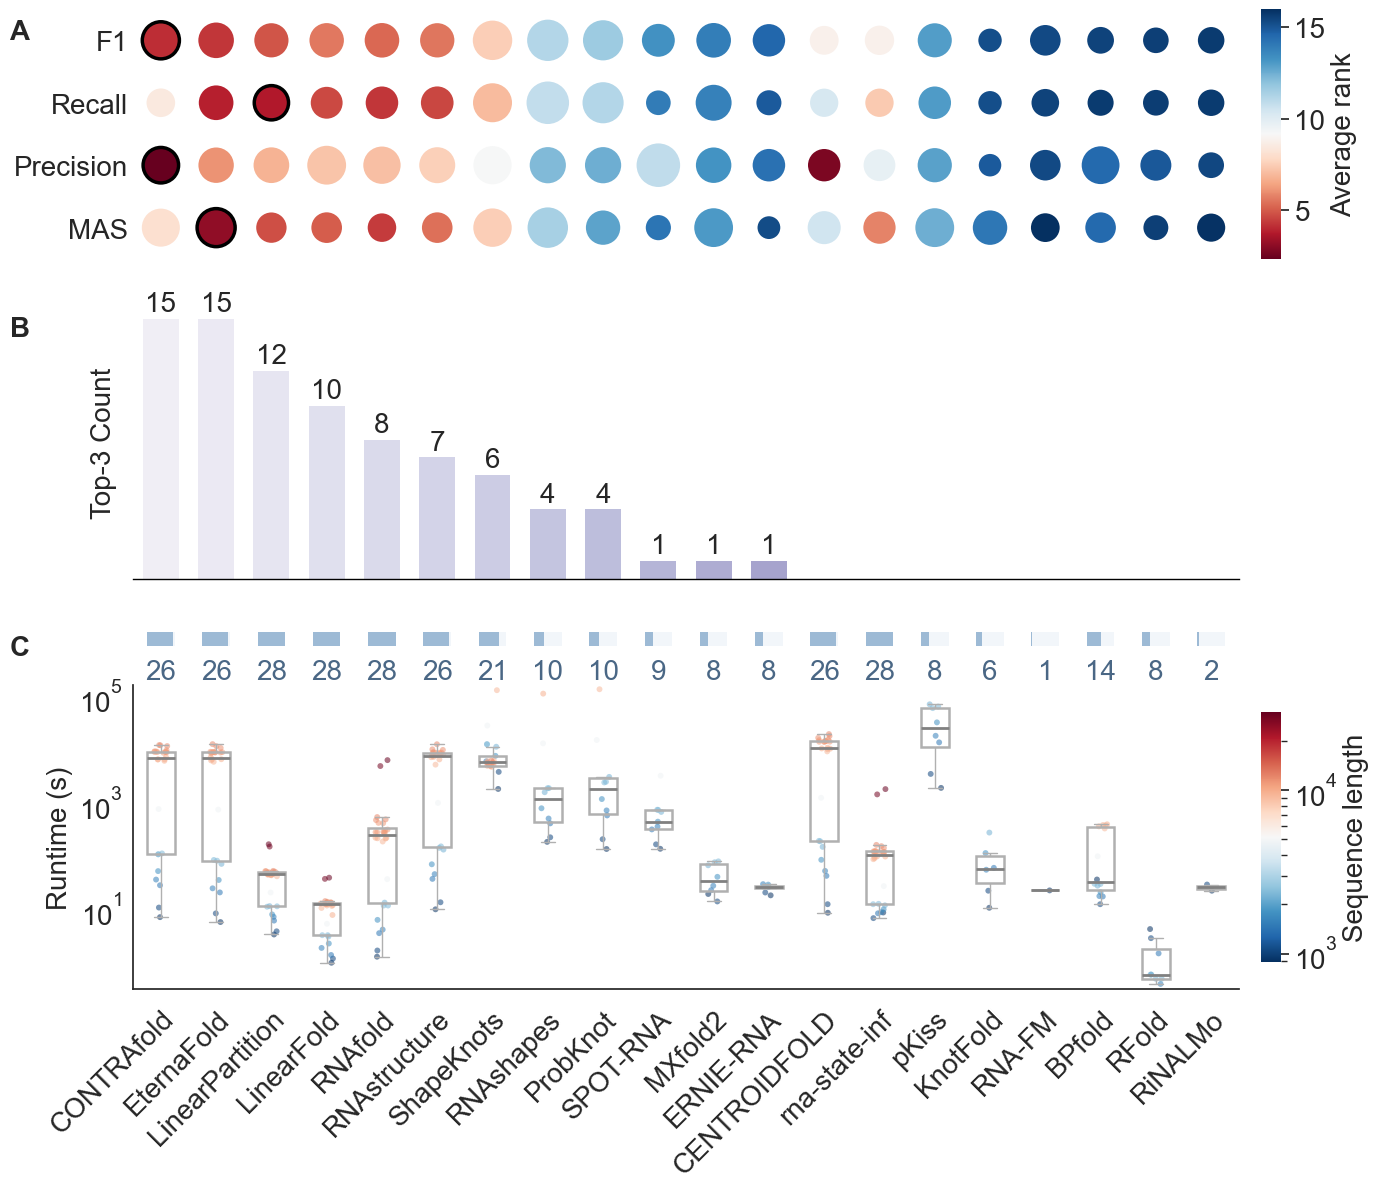

In [5]:
import matplotlib.colors as mcolors
from itertools import product
from matplotlib.patches import Rectangle
from matplotlib.ticker import LogLocator, LogFormatterMathtext

extended_methods = [
    "CONTRAfold", "LinearFold", "LinearPartition", "RNAfold", "RNAstructure", "CENTROIDFOLD",
    "ProbKnot", "ShapeKnots", "rna-state-inf", "MXfold2", "KnotFold", "RNAshapes",
    "pKiss", "SPOT-RNA", "RNA-FM", "BPfold", "RiNALMo", "RFold", "EternaFold", "ERNIE-RNA",
]
rank_metrics = {"F1": "F1", "Recall": "Sensitivity", "Precision": "Precision", "MAS": "MAS"}

results_rank_base = results[results["Method"].isin(extended_methods)].copy()
full_index_rank = pd.DataFrame(list(product(results_rank_base["ID"].unique(), extended_methods)), columns=["ID", "Method"])
results_ext = pd.merge(full_index_rank, results_rank_base, on=["ID", "Method"], how="left")
for col in ("Sensitivity", "Precision", "F1", "MAS"):
    results_ext[col] = results_ext[col].fillna(0)

average_ranks, rank_stds, per_sequence_ranks = {}, {}, {}
for display_metric, result_col in rank_metrics.items():
    pivot_metric = results_ext.pivot(index="ID", columns="Method", values=result_col)
    metric_ranks = pivot_metric.rank(axis=1, ascending=False, method="average")
    per_sequence_ranks[display_metric] = metric_ranks
    average_ranks[display_metric] = metric_ranks.mean(axis=0)
    rank_stds[display_metric] = metric_ranks.std(axis=0)

rank_heatmap = pd.DataFrame(average_ranks).loc[extended_methods].T
rank_std_heatmap = pd.DataFrame(rank_stds).loc[extended_methods].T

f1_ranks = per_sequence_ranks["F1"]
f1_average_rank = f1_ranks.mean(axis=0)
topk_counts = {}
for k in [1, 3, 5]:
    counts = (f1_ranks <= k).sum(axis=0)
    topk_counts[k] = pd.DataFrame({
        "Method": counts.index, "Count": counts.values,
        "F1_avg_rank": f1_average_rank.loc[counts.index].values,
    }).sort_values(by=["Count", "F1_avg_rank"], ascending=[False, True])


def plot_f1_mas_runtime_combined(progress_border=True, output_name="F1_MAS_runtime_combined.pdf", fig_height=12):
    panel_method_order = topk_counts[3]["Method"].tolist()
    n_methods = len(panel_method_order)
    fig_w = 14
    fig = plt.figure(figsize=(fig_w, fig_height), facecolor="white")

    margin_bottom_in, margin_top_in, margin_left_in, margin_right_in = 1.85, 0.35, 1.54, 0.98
    prog_row_in, count_row_in, progress_bar_thickness_in = 0.30, 0.24, 0.185
    bottom_frac, top_frac = margin_bottom_in / fig_height, 1 - margin_top_in / fig_height
    left_frac, right_frac = margin_left_in / fig_w, 1 - margin_right_in / fig_w
    usable_h_in = fig_height * (top_frac - bottom_frac)
    row_heights = np.array([0.55, 0.6, 0.8])
    row_heights_in = usable_h_in * row_heights / row_heights.sum()
    c_panel_in = row_heights_in[2]
    prog_ratio, count_ratio = prog_row_in / c_panel_in, count_row_in / c_panel_in

    gs = fig.add_gridspec(
        3, 2, height_ratios=row_heights.tolist(), width_ratios=[1.0, 0.018],
        hspace=0.16, wspace=0.04, left=left_frac, right=right_frac, top=top_frac, bottom=bottom_frac,
    )
    ax_a, cbar_ax, ax_b = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 0])
    gs_c = gs[2, 0].subgridspec(3, 1, height_ratios=[prog_ratio, count_ratio, 1.0], hspace=0.08)
    ax_c_top = fig.add_subplot(gs_c[0, 0])
    ax_c_count = fig.add_subplot(gs_c[1, 0], sharex=ax_c_top)
    ax_c = fig.add_subplot(gs_c[2, 0], sharex=ax_c_top)
    fig.add_subplot(gs[1, 1]).set_visible(False)
    cbar_len_ax = fig.add_subplot(gs[2, 1])

    NUM_FONTSIZE = PROGRESS_NUM_FONTSIZE = LABEL_FONTSIZE = 20
    PROGRESS_EDGE, PROGRESS_LW = "#1B4470", 1.6
    PROGRESS_BAR_H = progress_bar_thickness_in / prog_row_in
    PROGRESS_FILL, PROGRESS_TRACK = "#9DBAD5", "#F2F6FA"
    PANEL_LABEL_X = 0.022

    def style_method_xticklabels(ax, rotation=45):
        ax.xaxis.tick_bottom()
        plt.setp(ax.get_xticklabels(), rotation=rotation, ha="right", rotation_mode="anchor",
                 fontsize=LABEL_FONTSIZE, fontfamily="Arial", clip_on=False)
        ax.tick_params(axis="x", pad=8, labelbottom=True, labeltop=False, length=0)

    def place_panel_labels(fig, axes_labels):
        for ax, label in axes_labels:
            pos = ax.get_position()
            fig.text(PANEL_LABEL_X, pos.y1 - 0.008, label, transform=fig.transFigure, fontsize=20,
                     fontweight="bold", va="top", ha="left", fontfamily="Arial")

    rank_panel = rank_heatmap.loc[:, panel_method_order]
    rank_std_panel = rank_std_heatmap.loc[:, panel_method_order]
    std_values, max_std = rank_std_panel.values, np.nanmax(rank_std_panel.values)
    circle_min_size, circle_max_size = 120, 1100
    circle_sizes = (
        circle_min_size + (circle_max_size - circle_min_size) * std_values / max_std
        if max_std > 0 else np.full_like(std_values, circle_min_size)
    )
    rank_cmap = plt.get_cmap("RdBu")
    rank_norm = mcolors.Normalize(vmin=np.nanmin(rank_panel.values), vmax=np.nanmax(rank_panel.values))
    rank_face_colors = rank_cmap(rank_norm(rank_panel.values.ravel()))
    x_grid, y_grid = np.meshgrid(np.arange(rank_panel.shape[1]), np.arange(rank_panel.shape[0]))
    is_best = np.zeros(rank_panel.shape, dtype=bool)
    for row_idx in range(rank_panel.shape[0]):
        is_best[row_idx, rank_panel.iloc[row_idx].values.argmin()] = True
    circle_edge_colors = np.where(is_best.ravel(), "black", "white")
    circle_linewidths = np.where(is_best.ravel(), 2.5, 1.8)

    ax_a.scatter(x_grid.ravel(), y_grid.ravel(), s=circle_sizes.ravel(), facecolors=rank_face_colors,
                 edgecolors=circle_edge_colors, linewidths=circle_linewidths, zorder=2)
    ax_a.set_xlim(-0.5, n_methods - 0.5)
    ax_a.set_ylim(rank_panel.shape[0] - 0.5, -0.5)
    ax_a.set_xticks(np.arange(rank_panel.shape[1]))
    ax_a.set_xticklabels([])
    ax_a.tick_params(axis="x", labelbottom=False, length=0)
    ax_a.set_yticks(np.arange(rank_panel.shape[0]))
    ax_a.set_yticklabels(rank_panel.index, fontsize=LABEL_FONTSIZE, fontfamily="Arial")
    ax_a.tick_params(axis="y", labelsize=NUM_FONTSIZE, length=0)

    rank_mappable = plt.cm.ScalarMappable(norm=rank_norm, cmap=rank_cmap)
    rank_mappable.set_array([])
    cbar = fig.colorbar(rank_mappable, cax=cbar_ax, orientation="vertical")
    cbar.set_label("Average rank", fontsize=LABEL_FONTSIZE, fontfamily="Arial")
    cbar.ax.tick_params(labelsize=NUM_FONTSIZE)
    for label in cbar.ax.get_yticklabels():
        label.set_fontfamily("Arial")
    cbar.outline.set_visible(False)
    for spine in ax_a.spines.values():
        spine.set_visible(False)

    top3_df = topk_counts[3]
    bar_colors = plt.cm.Purples(np.linspace(0.12, 0.72, len(top3_df)))
    ax_b.bar(np.arange(len(top3_df)), top3_df["Count"], width=0.65, color=bar_colors, edgecolor="none", linewidth=0)
    for xpos, value in enumerate(top3_df["Count"]):
        if value > 0:
            ax_b.text(xpos, value + 0.1, f"{int(value)}", ha="center", va="bottom", fontsize=NUM_FONTSIZE, fontfamily="Arial")
    ax_b.set_xlim(-0.5, n_methods - 0.5)
    ax_b.set_xticklabels([])
    ax_b.tick_params(axis="x", labelbottom=False, length=0)
    ax_b.set_ylabel("Top-3 Count", fontsize=LABEL_FONTSIZE, fontfamily="Arial", labelpad=2)
    ax_b.set_yticks([])
    ax_b.tick_params(axis="y", left=False, labelleft=False)
    ax_b.yaxis.set_label_coords(-0.015, 0.5)
    for spine_name, spine in ax_b.spines.items():
        spine.set_visible(spine_name == "bottom")
        if spine_name == "bottom":
            spine.set_linewidth(1.0)
            spine.set_color("black")

    runtime_violin_df = plot_df[plot_df["runtime"] > 0].copy()
    runtime_violin_df["seq_len"] = runtime_violin_df["sequence"].map(seq_len_map)
    n_sequences = runtime_df.shape[1] - 1
    success_statuses = {"Success", "Success, no pairs"}
    success_counts = {
        method: int(status_matrix.loc[method].isin(success_statuses).sum()) if method in status_matrix.index else 0
        for method in panel_method_order
    }

    box_width = 0.5
    method_to_x = {m: i for i, m in enumerate(panel_method_order)}
    rng = np.random.default_rng(42)
    scatter_x = runtime_violin_df["method"].map(method_to_x).astype(float).to_numpy()
    scatter_x = scatter_x + rng.uniform(-0.12, 0.12, size=scatter_x.size)
    scatter_y = runtime_violin_df["runtime"].to_numpy()
    scatter_len = runtime_violin_df["seq_len"].to_numpy()
    len_norm = mcolors.LogNorm(
        vmin=float(np.nanmin(scatter_len)), vmax=float(np.nanmax(scatter_len)),
    )
    len_cmap = plt.get_cmap("RdBu_r")
    ax_c.scatter(
        scatter_x, scatter_y, c=scatter_len, cmap=len_cmap, norm=len_norm,
        s=18, alpha=0.55, edgecolors="none", zorder=2,
    )
    sns.boxplot(
        data=runtime_violin_df, x="method", y="runtime", order=panel_method_order, width=box_width, ax=ax_c,
        color="none", linewidth=1.2, showfliers=False,
        boxprops={"edgecolor": "#B0B0B0", "facecolor": "none", "linewidth": 1.8},
        medianprops={"color": "#808080", "linewidth": 2.0},
        whiskerprops={"color": "#B0B0B0", "linewidth": 1.0},
        capprops={"color": "#B0B0B0", "linewidth": 1.0}, zorder=5,
    )
    for patch in ax_c.patches:
        patch.set_facecolor("none")
        patch.set_edgecolor("#B0B0B0")
        patch.set_zorder(5)
    for line in ax_c.lines:
        line.set_zorder(6)
    len_mappable = plt.cm.ScalarMappable(norm=len_norm, cmap=len_cmap)
    len_mappable.set_array([])
    cbar_len = fig.colorbar(len_mappable, cax=cbar_len_ax, orientation="vertical")
    cbar_len.set_label("Sequence length", fontsize=LABEL_FONTSIZE, fontfamily="Arial")
    cbar_len.ax.tick_params(labelsize=NUM_FONTSIZE)
    for label in cbar_len.ax.get_yticklabels():
        label.set_fontfamily("Arial")
    cbar_len.outline.set_visible(False)

    y_lo, y_hi = runtime_violin_df["runtime"].min() * 0.8, runtime_violin_df["runtime"].max() * 1.2
    ax_c.set_yscale("log", base=10)
    ax_c.set_ylim(y_lo, y_hi)
    ax_c.yaxis.set_major_locator(LogLocator(base=10))
    ax_c.yaxis.set_minor_locator(LogLocator(base=10, subs=tuple(range(2, 10))))
    ax_c.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    ax_c.yaxis.set_minor_formatter(plt.NullFormatter())
    ax_c.spines["top"].set_visible(False)
    ax_c.spines["right"].set_visible(False)
    ax_c.set_xlabel("", fontsize=LABEL_FONTSIZE, fontfamily="Arial")
    ax_c.set_ylabel("Runtime (s)", fontsize=LABEL_FONTSIZE, fontfamily="Arial")
    style_method_xticklabels(ax_c)
    ax_c.tick_params(axis="x", pad=12)
    ax_c.tick_params(axis="y", which="both", labelsize=NUM_FONTSIZE, pad=2)
    for label in ax_c.get_yticklabels():
        label.set_fontfamily("Arial")

    n_runtime = n_methods
    ax_c_top.set_xlim(-0.5, n_runtime - 0.5)
    ax_c_top.set_ylim(0, 1)
    ax_c_top.axis("off")
    bar_y = 0.10
    for i, method in enumerate(panel_method_order):
        fill_w = box_width * success_counts[method] / n_sequences
        xy = (i - box_width / 2, bar_y)
        ax_c_top.add_patch(Rectangle(xy, box_width, PROGRESS_BAR_H, facecolor=PROGRESS_TRACK, edgecolor="none", linewidth=0, clip_on=False, zorder=10))
        ax_c_top.add_patch(Rectangle(xy, fill_w, PROGRESS_BAR_H, facecolor=PROGRESS_FILL, edgecolor="none", linewidth=0, clip_on=False, zorder=11))
        if progress_border:
            ax_c_top.add_patch(Rectangle(xy, box_width, PROGRESS_BAR_H, facecolor="none", edgecolor=PROGRESS_EDGE, linewidth=PROGRESS_LW, clip_on=False, zorder=12))

    ax_c_count.set_xlim(-0.5, n_runtime - 0.5)
    ax_c_count.set_ylim(0, 1)
    ax_c_count.axis("off")
    for i, method in enumerate(panel_method_order):
        ax_c_count.text(i, 0.92, f"{success_counts[method]}", ha="center", va="top", fontsize=PROGRESS_NUM_FONTSIZE,
                        fontfamily="Arial", color="#4A6785", clip_on=False, zorder=13)

    fig.canvas.draw()
    plot_left = max(ax.get_position().x0 for ax in (ax_a, ax_b, ax_c, ax_c_top, ax_c_count))
    plot_width = min(ax.get_position().width for ax in (ax_a, ax_b, ax_c, ax_c_top, ax_c_count))
    for ax in (ax_a, ax_b, ax_c, ax_c_top, ax_c_count):
        pos = ax.get_position()
        ax.set_position([plot_left, pos.y0, plot_width, pos.height])

    pos_a, pos_c, pos_cbar = ax_a.get_position(), ax_c.get_position(), cbar_ax.get_position()
    cbar_ax.set_position([pos_cbar.x0, pos_a.y0, pos_cbar.width, pos_a.height])
    cbar_h = pos_a.height
    cbar_y = pos_c.y0 + (pos_c.height - cbar_h) / 2
    cbar_len_ax.set_position([pos_cbar.x0, cbar_y, pos_cbar.width, cbar_h])

    ax_b.yaxis.set_label_coords(-0.015, 0.5)
    place_panel_labels(fig, [(ax_a, "A"), (ax_b, "B"), (ax_c_top, "C")])
    plt.savefig(fig_dir / output_name, format="pdf", dpi=350)
    plt.show()


plot_f1_mas_runtime_combined(progress_border=False, output_name="rank_F1top3_runtime.pdf", fig_height=12)


## Conditional F1 vs MAS rank correlation

Method-level and per-RNA Spearman / Kendall correlations between F1 and MAS rankings under the **conditional** setting.


In [6]:
from itertools import product
from scipy.stats import spearmanr, kendalltau

extended_methods = [
    "CONTRAfold", "LinearFold", "LinearPartition", "RNAfold", "RNAstructure", "CENTROIDFOLD",
    "ProbKnot", "ShapeKnots", "rna-state-inf", "MXfold2", "KnotFold", "RNAshapes", 
    "pKiss", "SPOT-RNA", "RNA-FM", "BPfold", "RiNALMo", "RFold", "EternaFold", "ERNIE-RNA",
]

full_index = pd.DataFrame(
    list(product(results["ID"].unique(), results["Method"].unique())),
    columns=["ID", "Method"],
)
results_cond = pd.merge(full_index, results, on=["ID", "Method"], how="left")
results_cond_ext = results_cond[results_cond["Method"].isin(extended_methods)].copy()

f1_pivot_cond = results_cond_ext.pivot(index="ID", columns="Method", values="F1").reindex(columns=extended_methods)
mas_pivot_cond = results_cond_ext.pivot(index="ID", columns="Method", values="MAS").reindex(columns=extended_methods)

f1_rank_cond = f1_pivot_cond.rank(axis=1, ascending=False, method="average")
mas_rank_cond = mas_pivot_cond.rank(axis=1, ascending=False, method="average")

method_rank_cond_df = pd.DataFrame({
    "Method": extended_methods,
    "F1_avg_rank": f1_rank_cond.mean(axis=0, skipna=True).reindex(extended_methods).values,
    "MAS_avg_rank": mas_rank_cond.mean(axis=0, skipna=True).reindex(extended_methods).values,
    "F1_n": f1_pivot_cond.notna().sum(axis=0).reindex(extended_methods).values,
    "MAS_n": mas_pivot_cond.notna().sum(axis=0).reindex(extended_methods).values,
}).sort_values("F1_avg_rank")

rho_method, p_rho_method = spearmanr(method_rank_cond_df["F1_avg_rank"], method_rank_cond_df["MAS_avg_rank"])
tau_method, p_tau_method = kendalltau(method_rank_cond_df["F1_avg_rank"], method_rank_cond_df["MAS_avg_rank"])

print("=" * 60)
print("Conditional F1 vs MAS rank correlation")
print("=" * 60)
print("Method-level average-rank correlation")
print(f"Spearman ρ = {rho_method:.4f}, p = {p_rho_method:.4e}")
print(f"Kendall  τ = {tau_method:.4f}, p = {p_tau_method:.4e}")
print(method_rank_cond_df.to_string(index=False))

per_rna_rows = []
for rna_id in f1_rank_cond.index:
    mask = f1_pivot_cond.loc[rna_id].notna() & mas_pivot_cond.loc[rna_id].notna()
    n_methods = int(mask.sum())
    if n_methods < 2:
        continue
    rho, p_rho = spearmanr(f1_rank_cond.loc[rna_id, mask], mas_rank_cond.loc[rna_id, mask])
    tau, p_tau = kendalltau(f1_rank_cond.loc[rna_id, mask], mas_rank_cond.loc[rna_id, mask])
    per_rna_rows.append({
        "ID": rna_id,
        "n_methods": n_methods,
        "Spearman_rho": rho,
        "Spearman_p": p_rho,
        "Kendall_tau": tau,
        "Kendall_p": p_tau,
    })

per_rna_corr = pd.DataFrame(per_rna_rows)
print("\n" + "=" * 60)
print("Per-RNA conditional rank correlation summary")
print("=" * 60)
print(f"Sequences used: {len(per_rna_corr)}")
print(per_rna_corr[["Spearman_rho", "Kendall_tau"]].describe().to_string())
print(
    f"\nMean Spearman ρ = {per_rna_corr['Spearman_rho'].mean():.4f} "
    f"(median {per_rna_corr['Spearman_rho'].median():.4f})"
)
print(
    f"Mean Kendall  τ = {per_rna_corr['Kendall_tau'].mean():.4f} "
    f"(median {per_rna_corr['Kendall_tau'].median():.4f})"
)


Conditional F1 vs MAS rank correlation
Method-level average-rank correlation
Spearman ρ = 0.8045, p = 1.9006e-05
Kendall  τ = 0.6105, p = 7.3219e-05
         Method  F1_avg_rank  MAS_avg_rank  F1_n  MAS_n
     CONTRAfold     3.500000      7.730769    26     26
     EternaFold     3.692308      2.384615    26     26
LinearPartition     4.892857      4.785714    28     28
      RNAshapes     5.000000      5.500000    10     10
   RNAstructure     5.019231      4.884615    26     26
        RNAfold     5.285714      4.392857    28     28
     ShapeKnots     5.357143      5.333333    21     21
     LinearFold     5.607143      5.071429    28     28
         RNA-FM     6.000000     14.000000     1      1
       ProbKnot     6.400000      9.400000    10     10
          pKiss     8.500000      6.500000     8      8
   CENTROIDFOLD     8.538462     10.384615    26     26
  rna-state-inf     8.857143      5.785714    28     28
       SPOT-RNA    10.444444     12.777778     9      9
        MXf